In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

import torch 
import torch.nn as nn
from torch.optim import Adam
from torch.distributions import Categorical

import gymnasium as gym 

In [84]:
env = gym.make("CartPole-v1",
                render_mode='rgb_array')

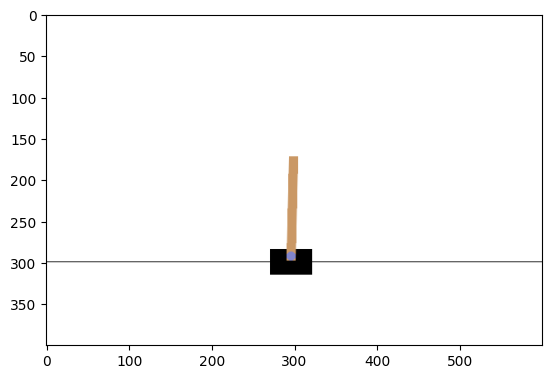

In [85]:
obs,_ = env.reset()
img = env.render()
plt.imshow(img)

In [86]:
class Model(nn.Module):
    def __init__(self, n_states,n_actions):
        super(Model,self).__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(n_states,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,n_actions),
            nn.Softmax(dim=-1) #output of fc layers will be (Batch_size,action value) so dim=-1 always
                               #applies softmax to last dim i.e the action value dim not to batch size
                               #eg: for (3,4(state_space)) bach of tensor, fc output is (3,2) (3 states,2 av each)
                               #so softmax is applies on the action value not the batch size


        )

    def forward(self,x):
        x = self.fc1(x)
        return x

In [87]:
class RLAgent:
    
    def __init__(self, env, n_states, n_actions, n_episodes, gamma=0.99):
        self.env = env
        self.n_states = n_states
        self.n_actions = n_actions
        self.n_episodes = n_episodes

        self.gamma = gamma
        self.lr = 1e-3


        self.reward_per_10epi = []
        self.epino_forplot = []
        self.all_rewards=[]

        self.rewards = []
        self.log_prob = []

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = Model(self.n_states,self.n_actions)
        self.policy_net.to(self.device)
        self.optim = Adam(self.policy_net.parameters(), lr=self.lr)




    def select_action(self,state):

        state = torch.tensor(state,dtype=torch.float32).unsqueeze(0).to(self.device)
        action_prob = self.policy_net(state)#.squeeze(0)
        
 
        distr = Categorical(probs=action_prob)  
        action = distr.sample()
        log_prob = distr.log_prob(action)
        self.log_prob.append(log_prob)
        #print(log_prob.shape)


        return action.item()  #items convers tensor to plain py int

    def compute_returns(self,rewards):
        # G = reward + gamma* G(-1)
        G = 0
        returns = []

        for reward in reversed(rewards):
            G = reward + (self.gamma * G)
            returns.append(G)

        returns = torch.tensor(returns[::-1], dtype=torch.float32)
        #returns = torch.tensor(returns,dtype=torch.float32)

        returns = (returns - returns.mean() )/ (returns.std() + 1e-8)

        #print(returns[:3])
        #print(self.rewards[:3])

        return returns



    def update(self):
        loss=0

        returns = self.compute_returns(self.rewards)
    

        for log_prob,G in zip(self.log_prob,returns):
            loss += (-log_prob * G)
        loss = loss
        #print(f"Loss: {loss.item():.4f}")  # add this
        #print(f"First log_prob: {self.log_prob[0].item():.4f}")  # add this
        #print(f"First return: {returns[0].item():.4f}")
        
        self.optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(),max_norm=1.0)
        self.optim.step()

        self.log_prob = []
        self.rewards = []

    #def shape_reward(self,state, reward):
    #    theta = state[2]
    #
    #    reward -= 2*abs(theta)   #angle penalty
    #    return reward

        

    def train(self):

        for episode in range(self.n_episodes):
            state,_ = self.env.reset()
            total_reward = 0
            done = False
            self.log_prob = []
            self.rewards = []

            while not done:
                action = self.select_action(state)
                next_state, reward, term, trunc, _ = self.env.step(action)
                #reward = self.shape_reward(state, reward)
                
                done = term or trunc

                total_reward+=reward

                self.rewards.append(reward)

                state = next_state

            self.update()
            
            self.all_rewards.append(total_reward)

            if episode % 10 == 0:
                self.epino_forplot.append(episode)
                avg_reward = np.mean(self.all_rewards[-10:])
                self.reward_per_10epi.append(avg_reward)
            
            avg = np.mean(self.all_rewards[-10:]) if self.all_rewards else 0
            print(f"Episode {episode} | Average_Reward: {avg:.2f} | Current_Reward: {total_reward:.2f}")

                                    
    def plot(self):
        moving_avg = np.convolve(self.all_rewards, np.ones(100)/100, mode='same')
        fig, ax = plt.subplots(figsize = (8,6))
        ax.plot(self.epino_forplot,self.reward_per_10epi,color='blue',label="Reward Per 10 Episodes")
        ax.plot(moving_avg, color='red', label="Moving Average")

        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.set_title("REINFORCE Training Progress")
        ax.legend(loc="upper left")
        plt.show()

In [88]:
Agent = RLAgent(env, 4, 2, 1000)

In [89]:
Agent.train()

Episode 0 | Average_Reward: 31.00 | Current_Reward: 31.00
Episode 1 | Average_Reward: 22.00 | Current_Reward: 13.00
Episode 2 | Average_Reward: 21.00 | Current_Reward: 19.00
Episode 3 | Average_Reward: 28.50 | Current_Reward: 51.00
Episode 4 | Average_Reward: 26.60 | Current_Reward: 19.00
Episode 5 | Average_Reward: 28.17 | Current_Reward: 36.00
Episode 6 | Average_Reward: 27.43 | Current_Reward: 23.00
Episode 7 | Average_Reward: 30.00 | Current_Reward: 48.00
Episode 8 | Average_Reward: 29.44 | Current_Reward: 25.00
Episode 9 | Average_Reward: 28.10 | Current_Reward: 16.00
Episode 10 | Average_Reward: 26.30 | Current_Reward: 13.00
Episode 11 | Average_Reward: 28.60 | Current_Reward: 36.00
Episode 12 | Average_Reward: 29.20 | Current_Reward: 25.00
Episode 13 | Average_Reward: 25.80 | Current_Reward: 17.00
Episode 14 | Average_Reward: 26.50 | Current_Reward: 26.00
Episode 15 | Average_Reward: 25.00 | Current_Reward: 21.00
Episode 16 | Average_Reward: 27.00 | Current_Reward: 43.00
Episode

KeyboardInterrupt: 

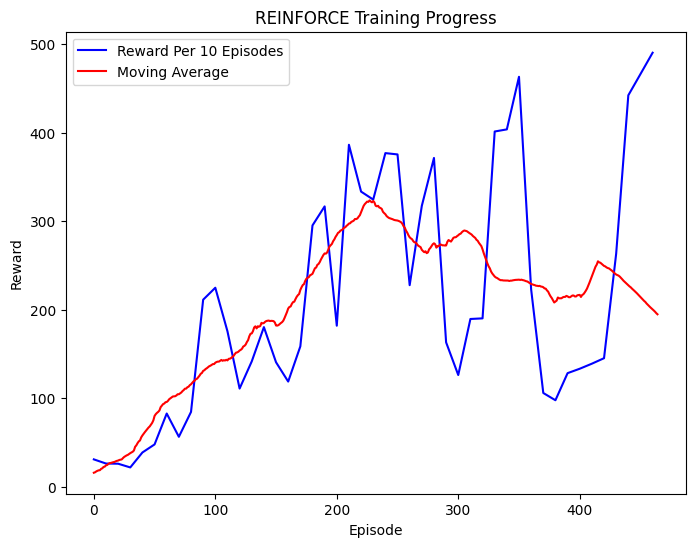

In [90]:
Agent.plot()

In [91]:
env = gym.make("CartPole-v1",render_mode='human')

for i in range(3):
    done = False
    total_reward = 0
    state,_ = env.reset()

    while not done:

        action = Agent.select_action(state)
        next_state, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        state = next_state
        total_reward += reward

    print(f'Total Reward This Episode: {total_reward}')
env.close()


Total Reward This Episode: 500.0
Total Reward This Episode: 460.0
Total Reward This Episode: 467.0
